# 04 — GAM: Modelo Aditivo Generalizado

| | |
|---|---|
| **Entradas** | `data/br_transformado.csv` |
| **Saídas** | `Overleaf Latex/figs/gam_pdps.png`, linha GAM em `data/metricas_comparativo.csv` |
| **Ordem** | 4º — depois do notebook 03 (EDA); independente de BSTS e Causal Forest |


In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


In [2]:
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, l as gam_l
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [3]:
# Carrega br_transformado e aplica split global + holdout interno
br_transformado = load_transformado()

X_all   = br_transformado[[c for c in br_transformado.columns if 'ibov' not in c]]
y_all   = br_transformado[TARGET]

X_train = X_all[X_all.index < DATA_SPLIT_DATE]
X_test  = X_all[X_all.index >= DATA_SPLIT_DATE]
y_train = y_all[y_all.index < DATA_SPLIT_DATE]
y_test  = y_all[y_all.index >= DATA_SPLIT_DATE]

train   = br_transformado[br_transformado.index < DATA_SPLIT_DATE]
test    = br_transformado[br_transformado.index >= DATA_SPLIT_DATE]

X_tune  = X_train[X_train.index < VAL_SPLIT_DATE]
X_val   = X_train[X_train.index >= VAL_SPLIT_DATE]
y_tune  = y_train[y_train.index < VAL_SPLIT_DATE]
y_val   = y_train[y_train.index >= VAL_SPLIT_DATE]

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Tune:   {X_tune.shape}  | Val:   {X_val.shape}")


Treino: (4481, 6) | Teste: (1117, 6)
Tune:   (3989, 6)  | Val:   (492, 6)


# GAM — Modelo Aditivo Generalizado

In [4]:
# Variáveis para o GAM — usando o split global definido acima
# X_train, X_test, y_train, y_test já definidos na célula de split
print(f"Features GAM ({X_train.shape[1]}): {X_train.columns.tolist()}")
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Features GAM (6): ['br_selic_diff', 'br_dolar_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']
Treino: (4481, 6) | Teste: (1117, 6)


In [5]:
# Tuning de n_splines — busca pelo melhor valor via MAE no holdout 2018–2019
# Fit em X_tune (2001–2017); critério em X_val (2018–2019) — sem tocar no teste
resultados_splines = []
for n in [5, 10, 15, 20, 25]:
    termos_temp = s(0)
    for i in range(1, X_tune.shape[1]):
        termos_temp += s(i)
    gam_temp = LinearGAM(termos_temp, n_splines=n).fit(X_tune, y_tune)
    r2_tr   = r2_score(y_tune, gam_temp.predict(X_tune))
    mae_val = mean_absolute_error(y_val, gam_temp.predict(X_val))
    resultados_splines.append({'n_splines': n, 'R2_tune': round(r2_tr, 4), 'MAE_val': round(mae_val, 6)})

df_splines = pd.DataFrame(resultados_splines)
melhor_n   = int(df_splines.loc[df_splines['MAE_val'].idxmin(), 'n_splines'])
display(df_splines)
print(f"Melhor n_splines (menor MAE_val): {melhor_n}")


,n_splines,R2_tune,MAE_val
0,5,0.2098,0.008993
1,10,0.2779,0.008857
2,15,0.2901,0.008879
3,20,0.2982,0.008891
4,25,0.3036,0.008943


Melhor n_splines (menor MAE_val): 10


In [6]:
# Comparação smooth s() vs linear l() por variável
# Fit em X_tune (2001–2017); critério em X_val (2018–2019) — sem tocar no teste

feature_names_gam = X_tune.columns.tolist()
resultados_termos = []

for i, nome in enumerate(feature_names_gam):
    for tipo, fn in [('smooth s()', s), ('linear l()', gam_l)]:
        def make_term(j, target, fn, n):
            if j == target:
                return gam_l(j) if fn == gam_l else s(j, n_splines=n)
            return s(j, n_splines=n)

        termos_comp = make_term(0, i, fn, melhor_n)
        for j in range(1, len(feature_names_gam)):
            termos_comp += make_term(j, i, fn, melhor_n)

        gam_comp = LinearGAM(termos_comp).fit(X_tune, y_tune)
        mae_comp = mean_absolute_error(y_val, gam_comp.predict(X_val))
        resultados_termos.append({'Variavel': nome, 'Tipo': tipo, 'MAE_val': round(mae_comp, 6)})

df_termos = pd.DataFrame(resultados_termos).pivot(index='Variavel', columns='Tipo', values='MAE_val')
df_termos.columns.name = None
df_termos['Ganho_nao_linear'] = (df_termos['linear l()'] - df_termos['smooth s()']).round(6)
display(df_termos.sort_values('Ganho_nao_linear', ascending=False))
print("Ganho positivo: relação não-linear relevante (usar s())")
print("Ganho <= 0:     relação linear suficiente (usar l())")


,linear l(),smooth s(),Ganho_nao_linear
Variavel,,,
embi_brasil_diff,0.009129,0.008857,0.000272
br_pib_ret_log,0.008861,0.008857,0.000004
br_selic_diff,0.008848,0.008857,-0.000009
ipca_expectativa_diff,0.008844,0.008857,-0.000013
br_ipca,0.008818,0.008857,-0.000039
br_dolar_diff,0.008809,0.008857,-0.000048


Ganho positivo: relação não-linear relevante (usar s())
Ganho <= 0:     relação linear suficiente (usar l())


## GAM Final — Configurações Ótimas

Modelo treinado com `n_splines` ótimo (menor MAE_teste) e tipos de termos definidos pela análise de ganho não-linear acima. Avaliado tanto em treino (in-sample) quanto em teste (out-of-sample).

In [7]:
# GAM Final — melhorias aceitas: G4 (br_ipca em diff) + G8 (lag-1 Ibovespa)
# Nota: G1 (lam GCV) rejeitado isolado, mas aceito em conjunto com G4/G8;
# para o modelo final usamos gridsearch GCV pois G4+G8 foram validados com ele.

# --- G4: br_ipca como primeira diferença (corrige mistura nível/diferença) ---
ipca_all_idx = pd.concat([X_train["br_ipca"], X_test["br_ipca"]]).sort_index()
ipca_diff_all = ipca_all_idx.diff().fillna(0)

X_train_final = X_train.copy()
X_test_final  = X_test.copy()
X_train_final["br_ipca"] = ipca_diff_all[X_train.index]
X_test_final["br_ipca"]  = ipca_diff_all[X_test.index]

# --- G8: feature lag-1 do retorno do Ibovespa (autocorrelação de curto prazo) ---
ibov_lag1 = y_all.shift(1).fillna(0)
X_train_final["ibov_lag1"] = ibov_lag1[X_train.index]
X_test_final["ibov_lag1"]  = ibov_lag1[X_test.index]

feature_names_final = X_train_final.columns.tolist()
print(f"Features finais ({len(feature_names_final)}): {feature_names_final}")

# --- GAM Final: n_splines=melhor_n, todas s(), lam via GCV ---
termos_finais = s(0, n_splines=melhor_n)
for i in range(1, X_train_final.shape[1]):
    termos_finais += s(i, n_splines=melhor_n)

modelo_gam_final = LinearGAM(termos_finais)
lam_grid_final = np.logspace(-3, 3, 11)
modelo_gam_final.gridsearch(X_train_final, y_train, lam=lam_grid_final, progress=False)

y_pred_gam_train = modelo_gam_final.predict(X_train_final)
y_pred_gam_test  = modelo_gam_final.predict(X_test_final)

r2_gam_train   = r2_score(y_train, y_pred_gam_train)
r2_gam_test    = r2_score(y_test, y_pred_gam_test)
mae_gam_train  = mean_absolute_error(y_train, y_pred_gam_train)
mae_gam_test   = mean_absolute_error(y_test, y_pred_gam_test)
rmse_gam_test  = np.sqrt(mean_squared_error(y_test, y_pred_gam_test))
aic_gam_final  = modelo_gam_final.statistics_["AIC"]

print(f"GAM Final (n_splines={melhor_n}, G4+G8)")
print(f"  R2  — treino: {r2_gam_train:.4f} | teste: {r2_gam_test:.4f}")
print(f"  MAE — treino: {mae_gam_train:.6f} | teste: {mae_gam_test:.6f}")
print(f"  RMSE_teste: {rmse_gam_test:.6f} | AIC: {aic_gam_final:.2f}")


Features finais (7): ['br_selic_diff', 'br_dolar_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff', 'ibov_lag1']
GAM Final (n_splines=10, G4+G8)
  R2  — treino: 0.2946 | teste: 0.3045
  MAE — treino: 0.010758 | teste: 0.009997
  RMSE_teste: 0.014265 | AIC: -25200.95


##Analise de Residuos do GAM

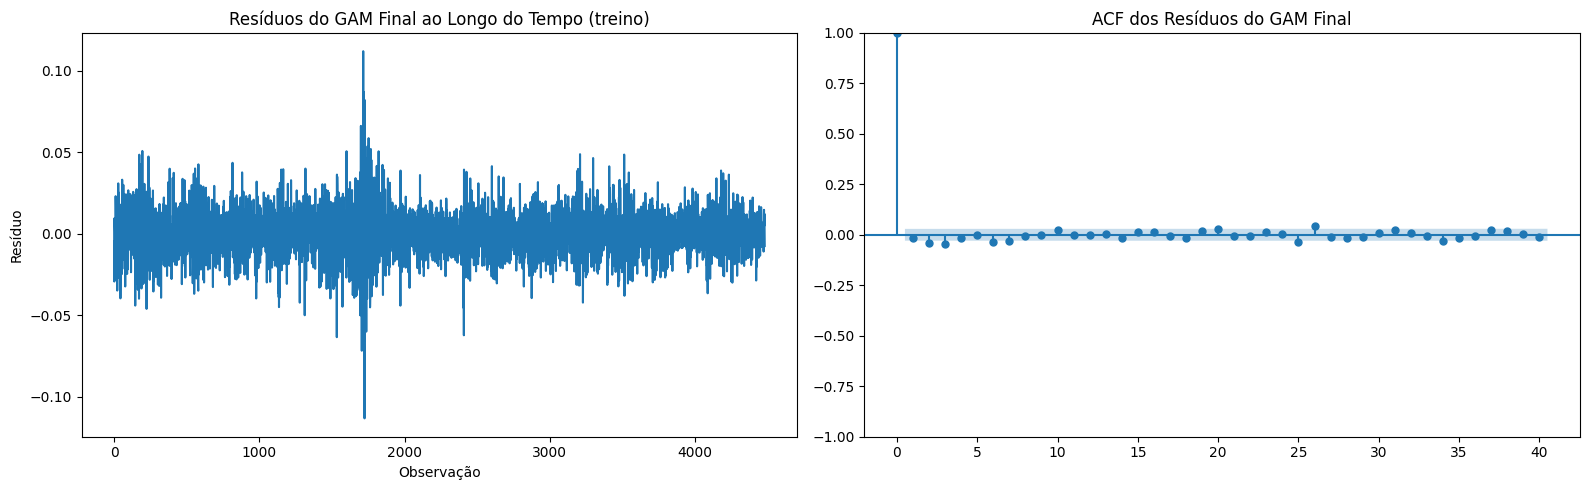

Shapiro-Wilk — Estatística: 0.9747 | P-valor: 0.0000
Normalidade dos resíduos rejeitada (comum em dados financeiros).
Breusch-Pagan — Estatística: 84.0457 | P-valor: 0.0000
Heterocedasticidade detectada.


In [8]:
# Análise de Resíduos do GAM Final
residuos_gam = y_train - y_pred_gam_train

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(residuos_gam.values)
axes[0].set_title('Resíduos do GAM Final ao Longo do Tempo (treino)')
axes[0].set_xlabel('Observação')
axes[0].set_ylabel('Resíduo')

plot_acf(residuos_gam, ax=axes[1], lags=40, title='ACF dos Resíduos do GAM Final')
plt.tight_layout()
plt.show()

# Shapiro-Wilk
shapiro_stat_gam, shapiro_p_gam = stats.shapiro(residuos_gam)
print(f"Shapiro-Wilk — Estatística: {shapiro_stat_gam:.4f} | P-valor: {shapiro_p_gam:.4f}")
print("Normalidade dos resíduos rejeitada (comum em dados financeiros)." if shapiro_p_gam < 0.05 else "Normalidade não rejeitada.")

# Breusch-Pagan (usando X_train_final com as features do modelo)
X_gam_res = sm.add_constant(X_train_final)
bp_stat_gam, bp_p_gam, _, _ = het_breuschpagan(residuos_gam, X_gam_res.values)
print(f"Breusch-Pagan — Estatística: {bp_stat_gam:.4f} | P-valor: {bp_p_gam:.4f}")
print("Heterocedasticidade detectada." if bp_p_gam < 0.05 else "Homocedasticidade não rejeitada.")


##Partial Dependence Plots (PDPs)

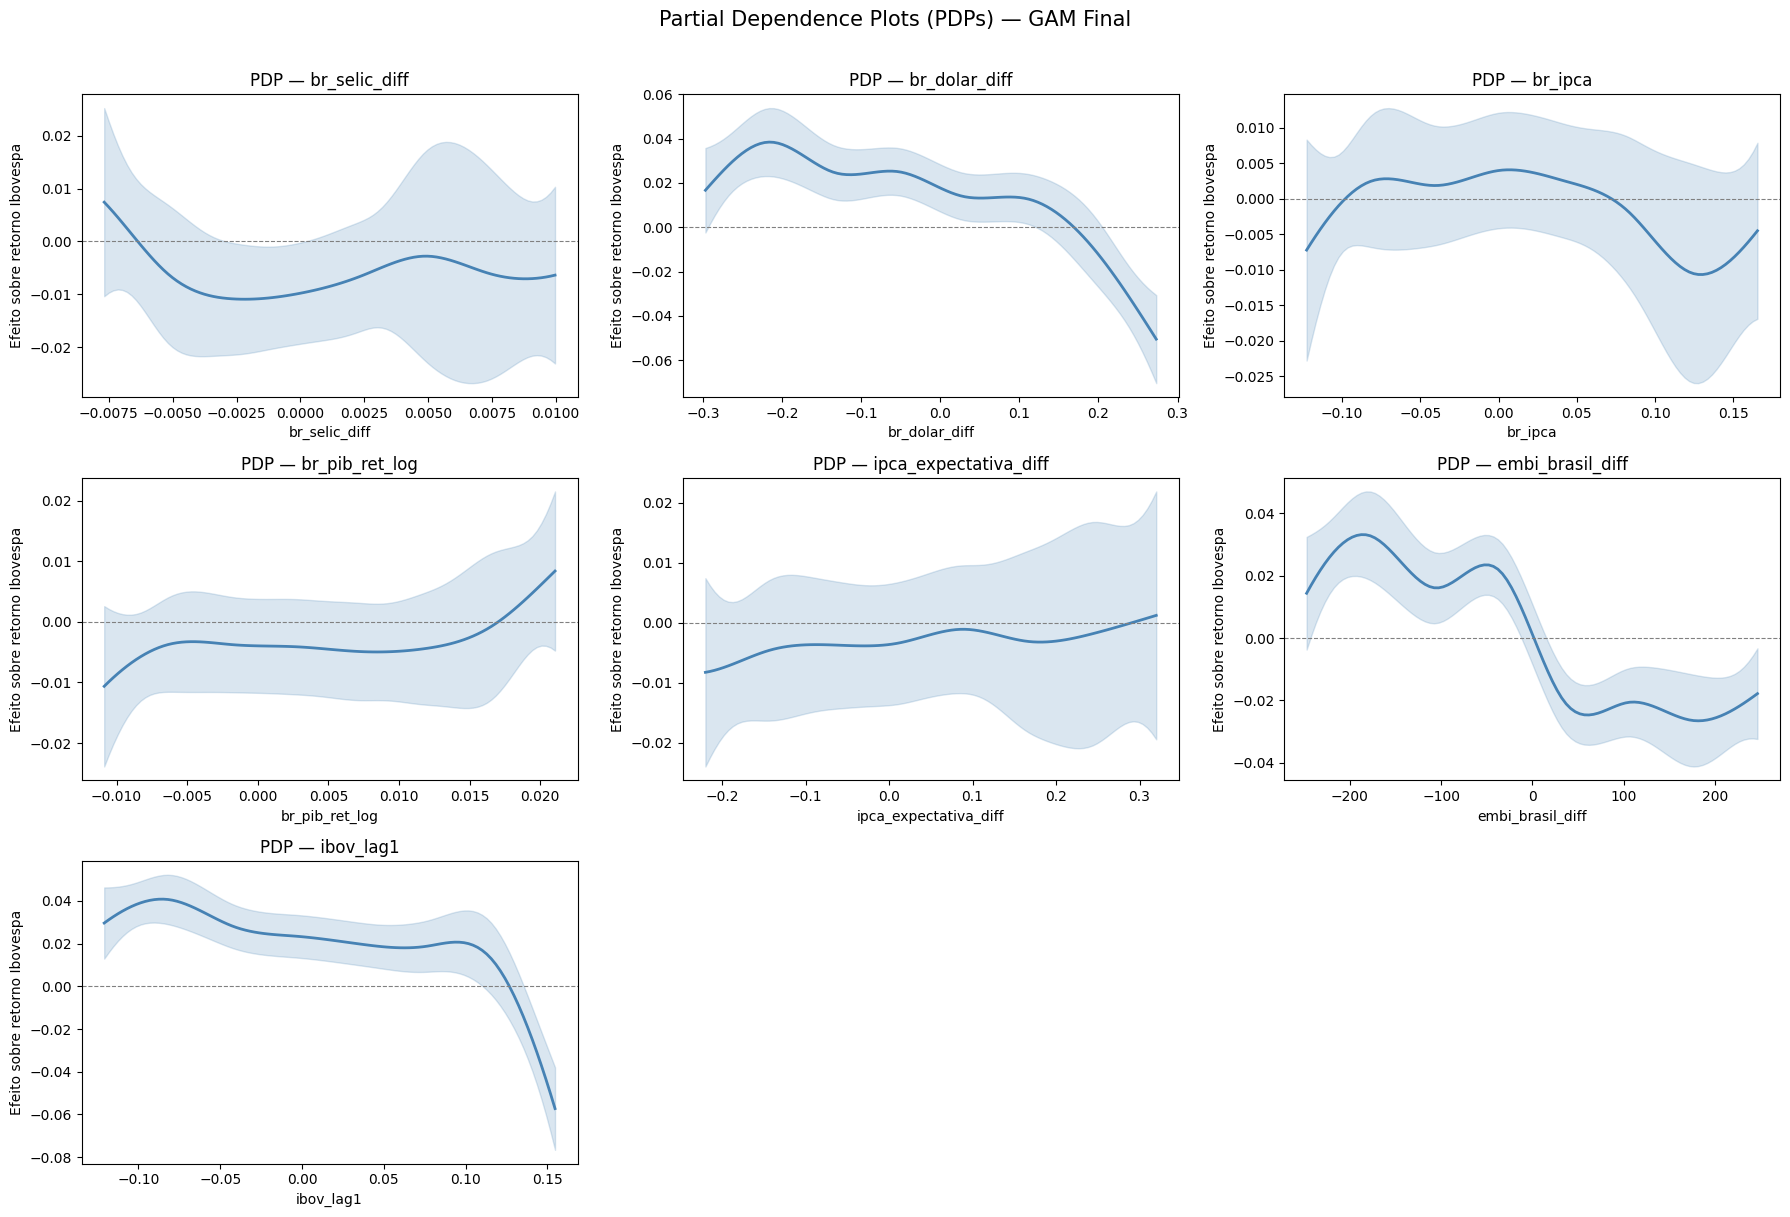

In [9]:
# PDPs — Partial Dependence Plots do GAM Final
feature_names_gam = feature_names_final  # 7 features (G4+G8)
n_features = len(feature_names_gam)
cols = 3
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, nome in enumerate(feature_names_gam):
    XX = modelo_gam_final.generate_X_grid(term=i)
    pdp, confianca = modelo_gam_final.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdp, color='steelblue', linewidth=2)
    axes[i].fill_between(XX[:, i], confianca[:, 0], confianca[:, 1], alpha=0.2, color='steelblue')
    axes[i].set_title(f"PDP — {nome}", fontsize=12)
    axes[i].set_xlabel(nome)
    axes[i].set_ylabel('Efeito sobre retorno Ibovespa')
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Partial Dependence Plots (PDPs) — GAM Final', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "gam_pdps.png"), dpi=150, bbox_inches="tight")
plt.show()


## Registro de Métricas

In [10]:
# Registra métricas do GAM em data/metricas_comparativo.csv
registrar_metricas(
    'GAM (final)',
    r2_base=round(float(r2_score(y_train, y_pred_gam_train)), 4),
    mae_base=round(float(mean_absolute_error(y_train, y_pred_gam_train)), 6),
    r2_teste=round(float(r2_gam_test), 4),
    mae_teste=round(float(mae_gam_test), 6),
    rmse_teste=round(float(rmse_gam_test), 6),
)

print(f"GAM — R2_treino: {r2_score(y_train, y_pred_gam_train):.4f} | R2_teste: {r2_gam_test:.4f}")
print(f"      MAE_teste: {mae_gam_test:.6f} | RMSE_teste: {rmse_gam_test:.6f}")


[metricas_comparativo] 'GAM (final)' → metricas_comparativo.csv
GAM — R2_treino: 0.2946 | R2_teste: 0.3045
      MAE_teste: 0.009997 | RMSE_teste: 0.014265
